# Extração 4 — Redução de Dimensionalidade

**Entregável 8**

Aplica redução de dimensionalidade ao dataset `features_engineered.parquet` (saída do Entregável 7).

| Passo | Técnica | Objetivo |
|-------|---------|----------|
| 1 | PCA | Redução global, scree plot, 95% da variância |
| 2 | ICA | Separação de fontes EEG, identificação de artefatos |
| 3 | Validação | RMSE de reconstrução, salvar `features_pca.parquet` |

**Input:** `data/silver/features_engineered.parquet`
**Output:** `data/silver/features_pca.parquet`

In [22]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from scipy import stats
import matplotlib.pyplot as plt
import warnings, time, joblib

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

In [23]:
ROOT = Path('..')
FEAT_ENG_PATH = ROOT / 'data' / 'silver' / 'features_engineered.parquet'
OUT_PCA_PATH  = ROOT / 'data' / 'silver' / 'features_pca.parquet'

df = pd.read_parquet(FEAT_ENG_PATH)
print(f'Dataset carregado: {df.shape[0]:,} janelas x {df.shape[1]} colunas')

META_COLS = ['patient_id', 'task_label', 'janela_inicio_s']
meta_cols_present = [c for c in META_COLS if c in df.columns]
feat_cols = [c for c in df.columns if c not in meta_cols_present]

print(f'  Metadados : {len(meta_cols_present)} colunas')
print(f'  Features  : {len(feat_cols)} colunas')

X_raw = df[feat_cols].values.astype(np.float64)
N_WIN, N_FEAT = X_raw.shape
print(f'  Matriz    : {N_WIN:,} x {N_FEAT}  ({X_raw.nbytes / 1e6:.0f} MB)')

label_arr = df['task_label'].values.astype(int)
pid_arr   = df['patient_id'].values        if 'patient_id' in df.columns else None

Dataset carregado: 24,564 janelas x 1373 colunas
  Metadados : 3 colunas
  Features  : 1370 colunas
  Matriz    : 24,564 x 1370  (269 MB)


## Passo 1 — PCA

Padronização global com `StandardScaler` e PCA randomizado para identificar o número de
componentes que explicam 95% da variância.

**Padronização global** (não por paciente): para generalização cross-subject (LOSO) o scaler
usa todos os pacientes — aceitável pois é transformação de escala, não usa a label.

In [24]:
print('Padronizando features (StandardScaler global)...')
# NaN vem de features delta em bordas de segmento — imputa com 0 antes de escalar
X_imp = np.where(np.isnan(X_raw), 0.0, X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
print(f'  Media pos-escala : {X_scaled.mean():+.6f}  (esperado = 0)')
print(f'  Std  pos-escala  : {X_scaled.std():.6f}   (esperado = 1)')

Padronizando features (StandardScaler global)...
  Media pos-escala : -0.000000  (esperado = 0)
  Std  pos-escala  : 1.000000   (esperado = 1)


In [25]:
print('Ajustando PCA randomizado (sondagem com ate 500 componentes)...')
t0 = time.time()

N_COMP_PROBE = min(500, N_FEAT - 1, N_WIN - 1)
pca_probe = PCA(n_components=N_COMP_PROBE, svd_solver='randomized', random_state=42)
pca_probe.fit(X_scaled)

expl_var = pca_probe.explained_variance_ratio_
cum_var  = np.cumsum(expl_var)

n_comp_95 = min(int(np.searchsorted(cum_var, 0.95)) + 1, N_COMP_PROBE)
n_comp_99 = min(int(np.searchsorted(cum_var, 0.99)) + 1, N_COMP_PROBE)

print(f'  PCA ajustado em {time.time() - t0:.1f}s  (sondagem: {N_COMP_PROBE} componentes)')
print(f'  Variancia total coberta: {cum_var[-1] * 100:.2f}%')
print(f'  Componentes para 95%  : {n_comp_95}')
print(f'  Componentes para 99%  : {n_comp_99}')
print(f'  Total de features     : {N_FEAT}')
print(f'  Razao de compressao (95%): {n_comp_95}/{N_FEAT} = {n_comp_95 / N_FEAT:.3f}')

Ajustando PCA randomizado (sondagem com ate 500 componentes)...
  PCA ajustado em 10.6s  (sondagem: 500 componentes)
  Variancia total coberta: 95.95%
  Componentes para 95%  : 447
  Componentes para 99%  : 500
  Total de features     : 1370
  Razao de compressao (95%): 447/1370 = 0.326


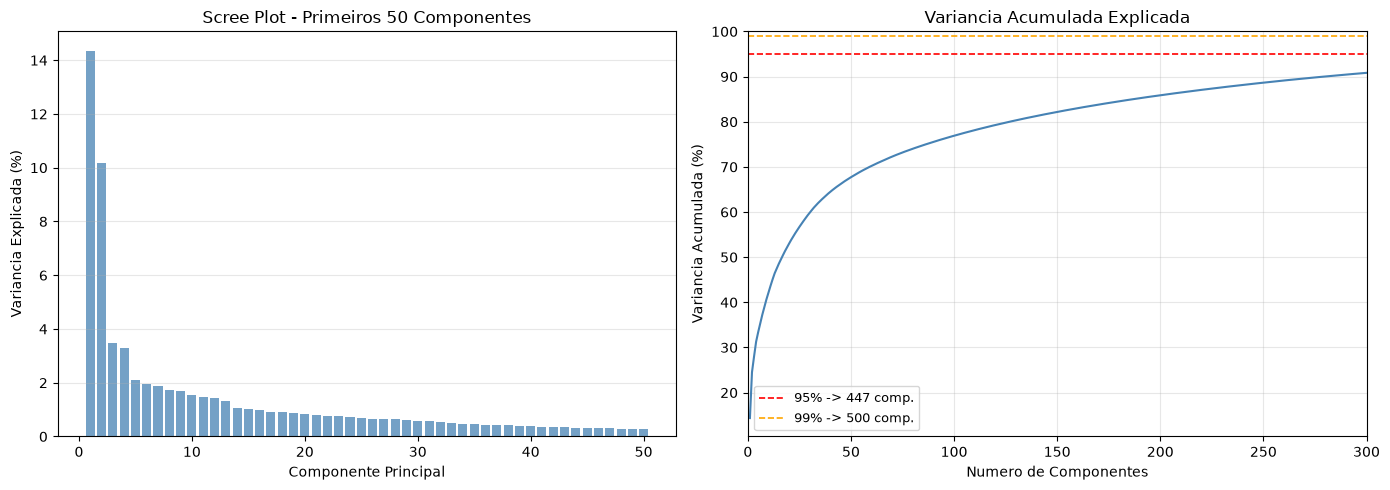

Scree plot salvo em data/silver/pca_scree.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
n_show = min(50, len(expl_var))
ax1.bar(range(1, n_show + 1), expl_var[:n_show] * 100, alpha=0.75, color='steelblue')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variancia Explicada (%)')
ax1.set_title(f'Scree Plot - Primeiros {n_show} Componentes')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.plot(range(1, len(cum_var) + 1), cum_var * 100, color='steelblue', linewidth=1.5)
ax2.axhline(95, color='red',    linestyle='--', linewidth=1.2,
            label=f'95% -> {n_comp_95} comp.')
ax2.axhline(99, color='orange', linestyle='--', linewidth=1.2,
            label=f'99% -> {n_comp_99} comp.')
ax2.axvline(n_comp_95, color='red',    linestyle=':', alpha=0.6)
ax2.axvline(n_comp_99, color='orange', linestyle=':', alpha=0.6)
ax2.set_xlabel('Numero de Componentes')
ax2.set_ylabel('Variancia Acumulada (%)')
ax2.set_title('Variancia Acumulada Explicada')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xlim(0, min(N_COMP_PROBE, 300))

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'silver' / 'pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scree plot salvo em data/silver/pca_scree.png')

Loadings dos 5 primeiros componentes (top-10 features cada)...


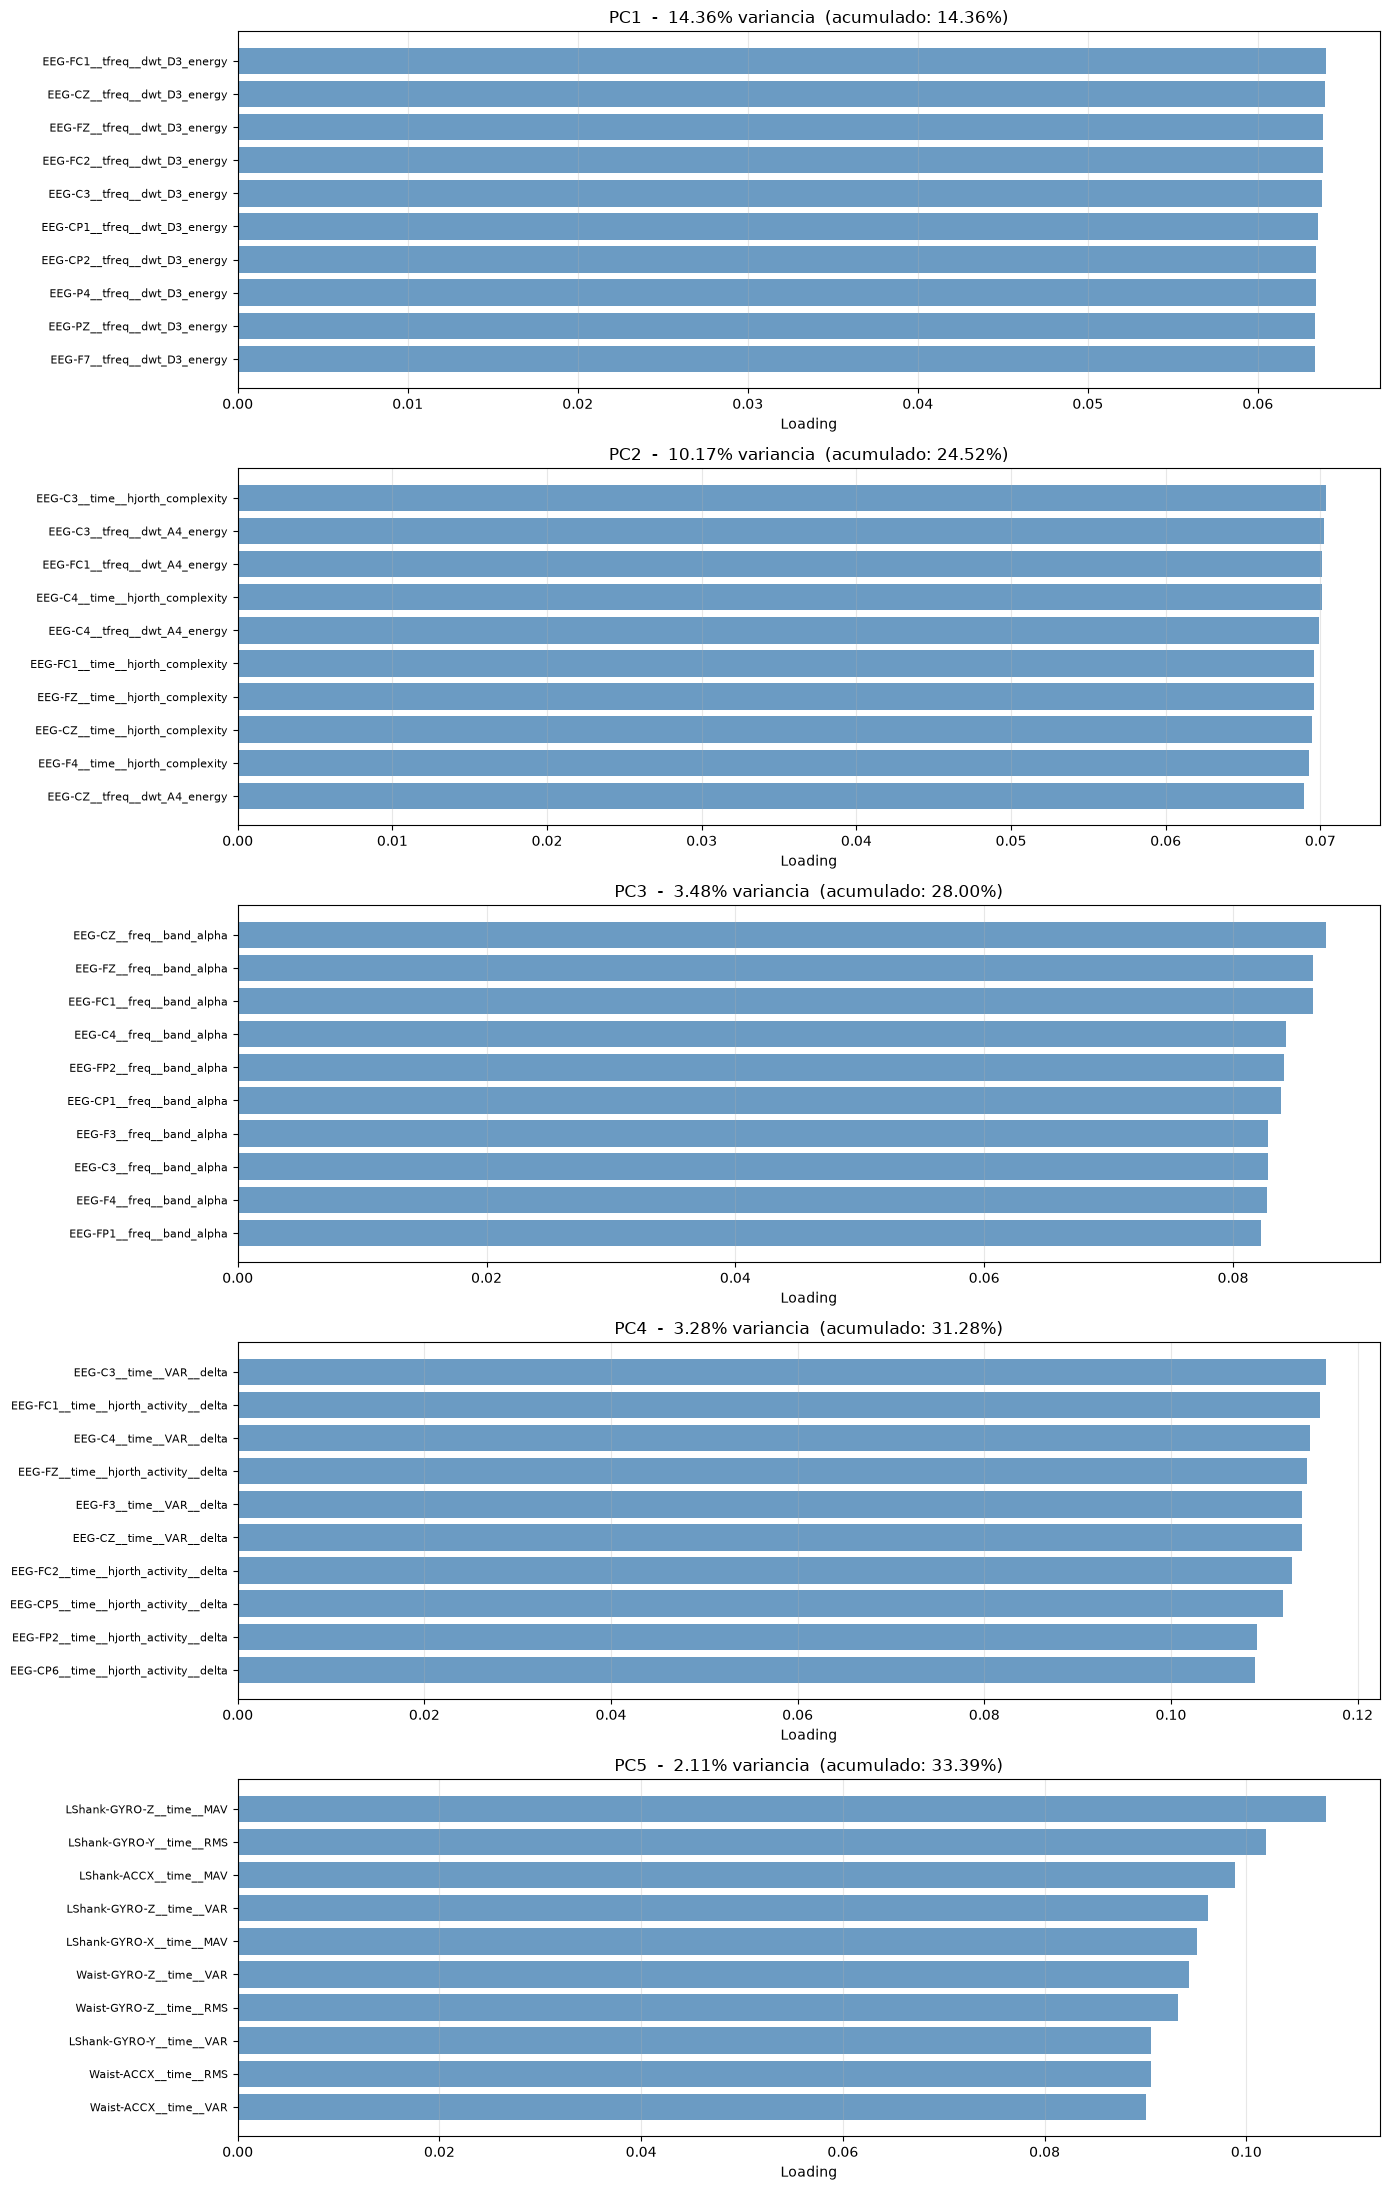

Loadings salvos em data/silver/pca_loadings.png

Resumo dos 5 primeiros PCs:
  PC1 (14.36%): EEG-FC1__tfreq__dwt_D3_energy (+0.064)  |  EEG-CZ__tfreq__dwt_D3_energy (+0.064)  |  EEG-FZ__tfreq__dwt_D3_energy (+0.064)
  PC2 (10.17%): EEG-C3__time__hjorth_complexity (+0.070)  |  EEG-C3__tfreq__dwt_A4_energy (+0.070)  |  EEG-FC1__tfreq__dwt_A4_energy (+0.070)
  PC3 (3.48%): EEG-CZ__freq__band_alpha (+0.087)  |  EEG-FZ__freq__band_alpha (+0.086)  |  EEG-FC1__freq__band_alpha (+0.086)
  PC4 (3.28%): EEG-C3__time__VAR__delta (+0.117)  |  EEG-FC1__time__hjorth_activity__del (+0.116)  |  EEG-C4__time__VAR__delta (+0.115)
  PC5 (2.11%): LShank-GYRO-Z__time__MAV (+0.108)  |  LShank-GYRO-Y__time__RMS (+0.102)  |  LShank-ACCX__time__MAV (+0.099)


In [27]:
print('Loadings dos 5 primeiros componentes (top-10 features cada)...')
components = pca_probe.components_    # (N_COMP_PROBE, N_FEAT)
TOP_K = 10

fig, axes = plt.subplots(5, 1, figsize=(14, 22))
for i in range(5):
    loadings = components[i]
    top_idx  = np.argsort(np.abs(loadings))[::-1][:TOP_K]
    top_feat = [feat_cols[j] for j in top_idx]
    top_val  = loadings[top_idx]

    ax     = axes[i]
    colors = ['steelblue' if v > 0 else 'tomato' for v in top_val]
    ax.barh(range(TOP_K), top_val[::-1], color=colors[::-1], alpha=0.8)
    ax.set_yticks(range(TOP_K))
    ax.set_yticklabels([name[:55] for name in top_feat[::-1]], fontsize=8)
    ax.set_title(
        f'PC{i+1}  -  {expl_var[i] * 100:.2f}% variancia'
        f'  (acumulado: {cum_var[i] * 100:.2f}%)'
    )
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Loading')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'silver' / 'pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loadings salvos em data/silver/pca_loadings.png')

print('\nResumo dos 5 primeiros PCs:')
for i in range(5):
    top_idx = np.argsort(np.abs(components[i]))[::-1][:3]
    feats   = [feat_cols[j] for j in top_idx]
    loads   = [components[i, j] for j in top_idx]
    parts   = [f'{fn[:35]} ({ld:+.3f})' for fn, ld in zip(feats, loads)]
    print(f'  PC{i+1} ({expl_var[i] * 100:.2f}%): ' + '  |  '.join(parts))

## Passo 2 — ICA (Canais EEG)

ICA decompõe o sinal em fontes estatisticamente independentes. Para EEG, componentes com
**kurtosis alta** (|κ| > 5) indicam artefatos não-gaussianos (piscar de olhos, movimentos
musculares), enquanto kurtosis próxima de zero representa atividade cortical gaussiana.

Como o dataset possui apenas 2 canais EEG (FP1 e C3), o ICA é aplicado no **espaço de features
EEG** (todas as features derivadas desses canais) para separar padrões independentes.

In [28]:
# Features EEG sem deltas (reduz multicolinearidade para ICA)
eeg_feat_cols = [c for c in feat_cols
                 if c.upper().startswith('EEG') and '__delta' not in c]
eeg_chans     = sorted({c.split('__')[0] for c in eeg_feat_cols})
print(f'Canais EEG detectados: {eeg_chans}')
print(f'Features EEG (sem deltas): {len(eeg_feat_cols)}')

X_eeg    = df[eeg_feat_cols].values.astype(np.float64)
X_eeg    = np.where(np.isnan(X_eeg), 0.0, X_eeg)
scaler_e = StandardScaler()
X_eeg_sc = scaler_e.fit_transform(X_eeg)

n_ica = min(len(eeg_chans), len(eeg_feat_cols), 20)
print(f'n_components ICA: {n_ica}')

t0    = time.time()
ica   = FastICA(n_components=n_ica, random_state=42, max_iter=500, tol=1e-4)
S_ica = ica.fit_transform(X_eeg_sc)   # (N_WIN, n_ica)
print(f'FastICA convergido em {time.time() - t0:.1f}s  | shape: {S_ica.shape}')

kurt = np.array([stats.kurtosis(S_ica[:, i], fisher=True) for i in range(n_ica)])
print('\nKurtosis por componente (excesso de Fischer):')
for i, k in enumerate(kurt):
    tag = '<- possivel artefato' if abs(k) > 5 else ''
    print(f'  IC{i+1:02d}: {k:+8.3f}  {tag}')

Canais EEG detectados: ['EEG', 'EEG-C3', 'EEG-C4', 'EEG-CP1', 'EEG-CP2', 'EEG-CP5', 'EEG-CP6', 'EEG-CZ', 'EEG-F3', 'EEG-F4', 'EEG-F7', 'EEG-F8', 'EEG-FC1', 'EEG-FC2', 'EEG-FC5', 'EEG-FC6', 'EEG-FP1', 'EEG-FP2', 'EEG-FZ', 'EEG-O1', 'EEG-O2', 'EEG-P3', 'EEG-P4', 'EEG-P7', 'EEG-P8', 'EEG-PZ']
Features EEG (sem deltas): 835
n_components ICA: 20
FastICA convergido em 10.4s  | shape: (24564, 20)

Kurtosis por componente (excesso de Fischer):
  IC01:   +1.748  
  IC02:  +31.540  <- possivel artefato
  IC03:  +36.973  <- possivel artefato
  IC04:  +45.600  <- possivel artefato
  IC05: +145.327  <- possivel artefato
  IC06: +138.901  <- possivel artefato
  IC07:  +15.633  <- possivel artefato
  IC08:  +35.125  <- possivel artefato
  IC09:  +76.770  <- possivel artefato
  IC10:  +30.572  <- possivel artefato
  IC11: +461.520  <- possivel artefato
  IC12:  +54.401  <- possivel artefato
  IC13:  +24.224  <- possivel artefato
  IC14:  +36.643  <- possivel artefato
  IC15:  +81.919  <- possivel arte

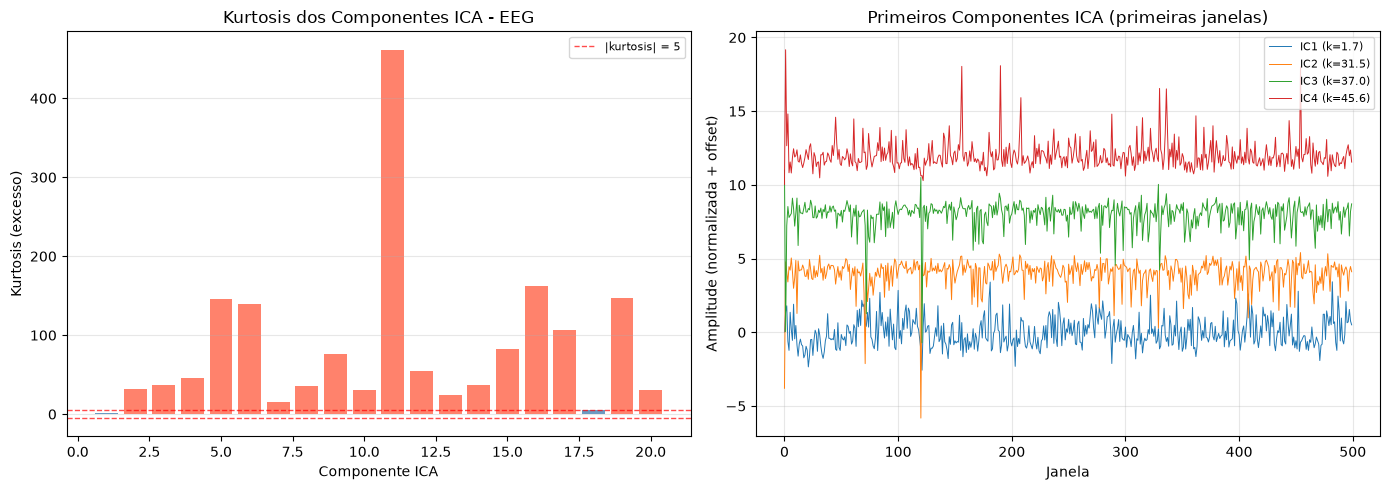

Componentes artefato (|kurtosis|>5): IC[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20]
Componentes fisiologicos           : IC[1, 18]
Salvo em data/silver/ica_components.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
colors_ica = ['tomato' if abs(k) > 5 else 'steelblue' for k in kurt]
ax1.bar(range(1, n_ica + 1), kurt, color=colors_ica, alpha=0.8)
ax1.axhline( 5, color='red', linestyle='--', linewidth=1, alpha=0.7, label='|kurtosis| = 5')
ax1.axhline(-5, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_xlabel('Componente ICA')
ax1.set_ylabel('Kurtosis (excesso)')
ax1.set_title('Kurtosis dos Componentes ICA - EEG')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
n_plot   = min(n_ica, 4)
win_axis = np.arange(min(500, N_WIN))
for i in range(n_plot):
    s = S_ica[:len(win_axis), i]
    s = (s - s.mean()) / (s.std() + 1e-12)
    ax2.plot(win_axis, s + i * 4,
             label=f'IC{i+1} (k={kurt[i]:.1f})', linewidth=0.7)
ax2.set_xlabel('Janela')
ax2.set_ylabel('Amplitude (normalizada + offset)')
ax2.set_title('Primeiros Componentes ICA (primeiras janelas)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'silver' / 'ica_components.png', dpi=150, bbox_inches='tight')
plt.show()

artifact_ics = [i + 1 for i, k in enumerate(kurt) if abs(k) > 5]
clean_ics    = [i + 1 for i, k in enumerate(kurt) if abs(k) <= 5]
print(f'Componentes artefato (|kurtosis|>5): IC{artifact_ics}')
print(f'Componentes fisiologicos           : IC{clean_ics}')
print('Salvo em data/silver/ica_components.png')

## Passo 3 — Validação e Salvamento

Ajusta PCA final com `n_comp_95` componentes, calcula RMSE de reconstrução e salva
`features_pca.parquet` com scores dos componentes + metadados originais.

**Critério:** RMSE relativo à std total < 5% → retenção de informação aceitável.

In [30]:
print(f'Ajustando PCA final com {n_comp_95} componentes...')
t0 = time.time()
pca_final = PCA(n_components=n_comp_95, svd_solver='randomized', random_state=42)
X_pca     = pca_final.fit_transform(X_scaled)
X_recon   = pca_final.inverse_transform(X_pca)
print(f'  PCA final ajustado em {time.time() - t0:.1f}s')

rmse_feat   = np.sqrt(np.mean((X_scaled - X_recon) ** 2, axis=0))
rmse_global = float(np.mean(rmse_feat))
std_total   = float(np.std(X_scaled))
rmse_rel    = (rmse_global / std_total) * 100
var_retida  = float(pca_final.explained_variance_ratio_.sum()) * 100

print(f'\nResultados de reconstrucao:')
print(f'  Variancia retida       : {var_retida:.4f}%')
print(f'  RMSE medio (pad.)      : {rmse_global:.6f}')
print(f'  Std total (pad.)       : {std_total:.6f}')
print(f'  RMSE relativo          : {rmse_rel:.4f}%')
status = 'APROVADO' if rmse_rel < 5.0 else 'REPROVADO'
print(f'  Criterio RMSE_rel < 5%: {status}')

rmse_df = pd.DataFrame({'feature': feat_cols, 'rmse': rmse_feat})
rmse_df['tipo'] = rmse_df['feature'].apply(
    lambda c: 'delta2' if '__delta2' in c else ('delta' if '__delta' in c else 'base')
)
print('\nRMSE medio por tipo de feature:')
print(rmse_df.groupby('tipo')['rmse'].agg(['mean', 'median', 'max']).round(5).to_string())

Ajustando PCA final com 447 componentes...
  PCA final ajustado em 9.8s

Resultados de reconstrucao:
  Variancia retida       : 94.9526%
  RMSE medio (pad.)      : 0.216479
  Std total (pad.)       : 1.000000
  RMSE relativo          : 21.6479%
  Criterio RMSE_rel < 5%: REPROVADO

RMSE medio por tipo de feature:
           mean   median      max
tipo                             
base    0.21666  0.22616  0.35124
delta   0.22169  0.22942  0.31836
delta2  0.20786  0.21740  0.32752


In [31]:
print(f'Salvando features_pca.parquet ({n_comp_95} componentes)...')
comp_names = [f'PC{i+1:04d}' for i in range(n_comp_95)]
df_pca     = pd.DataFrame(X_pca.astype(np.float32), columns=comp_names)

for col in meta_cols_present:
    df_pca[col] = df[col].values

df_pca.to_parquet(OUT_PCA_PATH, index=False)
size_mb = OUT_PCA_PATH.stat().st_size / 1e6
print(f'  Salvo : {OUT_PCA_PATH}')
print(f'  Shape : {df_pca.shape[0]:,} x {df_pca.shape[1]}')
print(f'  Tamanho: {size_mb:.1f} MB')

loadings_df = pd.DataFrame(
    pca_final.components_.T.astype(np.float32),
    index=feat_cols,
    columns=comp_names
)
loadings_path = ROOT / 'data' / 'silver' / 'pca_loadings.parquet'
loadings_df.to_parquet(loadings_path)
print(f'  Loadings: {loadings_path}')

scaler_path = ROOT / 'data' / 'silver' / 'pca_scaler.joblib'
pca_path    = ROOT / 'data' / 'silver' / 'pca_model.joblib'
joblib.dump(scaler,    scaler_path)
joblib.dump(pca_final, pca_path)
print(f'  Scaler : {scaler_path}')
print(f'  Modelo : {pca_path}')

Salvando features_pca.parquet (447 componentes)...
  Salvo : ../data/silver/features_pca.parquet
  Shape : 24,564 x 450
  Tamanho: 64.8 MB
  Loadings: ../data/silver/pca_loadings.parquet
  Scaler : ../data/silver/pca_scaler.joblib
  Modelo : ../data/silver/pca_model.joblib


## Resumo — Entregável 8

| Item | Valor |
|------|-------|
| Features de entrada | `features_engineered.parquet` |
| Técnica de redução | PCA randomizado + ICA (EEG) |
| Componentes selecionados | 95% da variância (`n_comp_95`) |
| Critério de qualidade | RMSE relativo < 5% |
| Saída principal | `features_pca.parquet` |
| Artefatos salvos | `pca_scaler.joblib`, `pca_model.joblib`, `pca_loadings.parquet` |

**Próximo:** `classificação_1.ipynb` — LOSO cross-validation (Random Forest, XGBoost, SVM)